# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv('cleaned_aviation_data.csv')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
small_planes = df[df['Total.Occupants'] < 20].copy()
large_planes = df[df['Total.Occupants'] >= 20].copy()

print(f"small planes: {len(small_planes)}")
print(f"large planes: {len(large_planes)}")

small planes: 64975
large planes: 2560


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

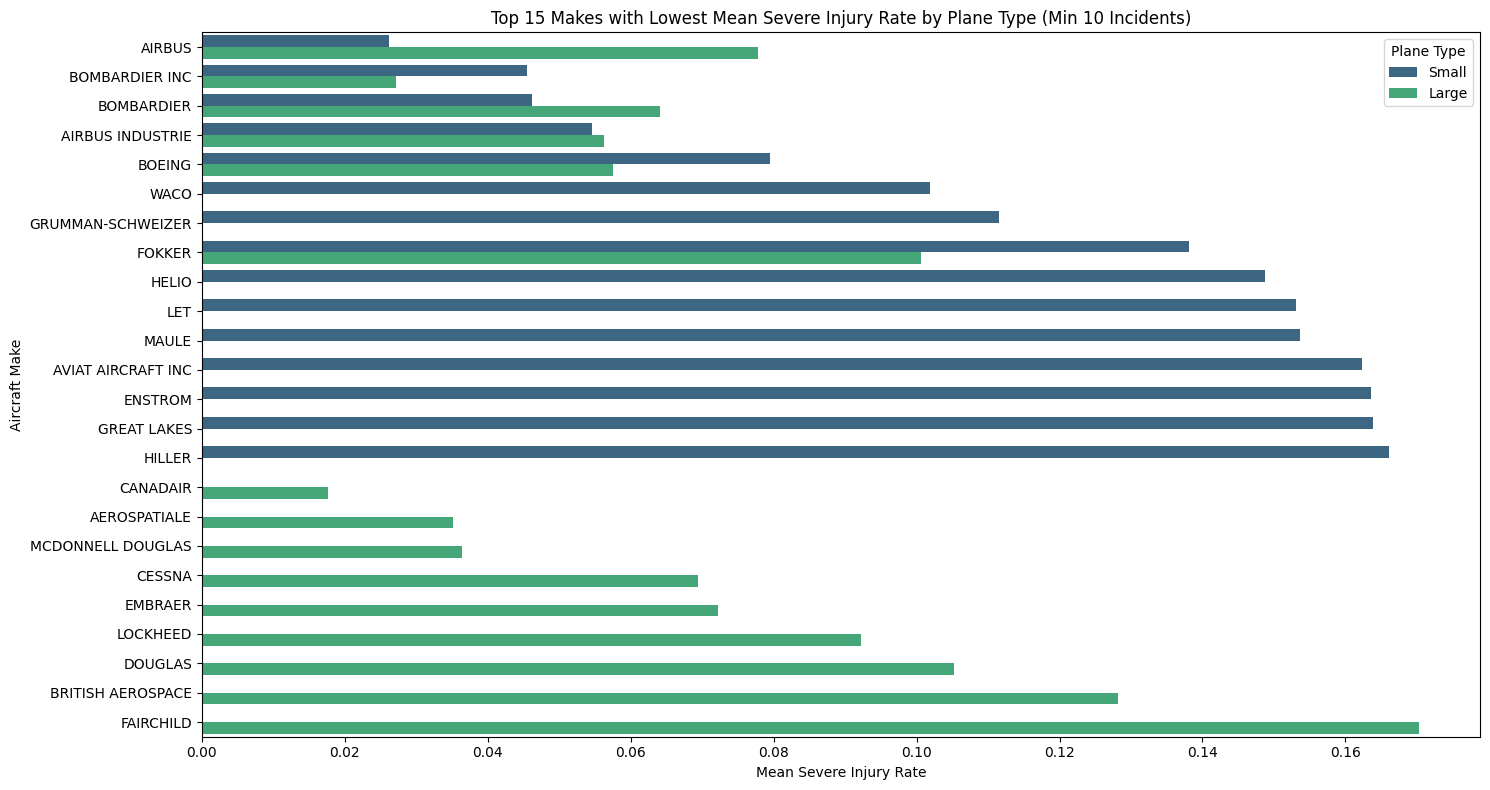

In [5]:
# Calculate mean severe injury rate for small planes and select top 15
make_counts_small = small_planes['Make'].value_counts()
small_planes_filtered = small_planes[small_planes['Make'].isin(make_counts_small[make_counts_small >= 10].index)]
small_makes_injury_rate = small_planes_filtered.groupby('Make')['Severe.Injury.Rate'].mean().sort_values().head(15)

# Calculate mean severe injury rate for large planes and select top 15
make_counts_large = large_planes['Make'].value_counts()
large_planes_filtered = large_planes[large_planes['Make'].isin(make_counts_large[make_counts_large >= 10].index)]
large_makes_injury_rate = large_planes_filtered.groupby('Make')['Severe.Injury.Rate'].mean().sort_values().head(15)

# Prepare data for plotting
plot_data_small = small_makes_injury_rate.reset_index()
plot_data_small['Plane Type'] = 'Small'

plot_data_large = large_makes_injury_rate.reset_index()
plot_data_large['Plane Type'] = 'Large'

combined_plot_data = pd.concat([plot_data_small, plot_data_large])

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x='Severe.Injury.Rate', y='Make', hue='Plane Type', data=combined_plot_data, palette='viridis')
plt.title('Top 15 Makes with Lowest Mean Severe Injury Rate by Plane Type (Min 10 Incidents)')
plt.xlabel('Mean Severe Injury Rate')
plt.ylabel('Aircraft Make')
plt.legend(title='Plane Type')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

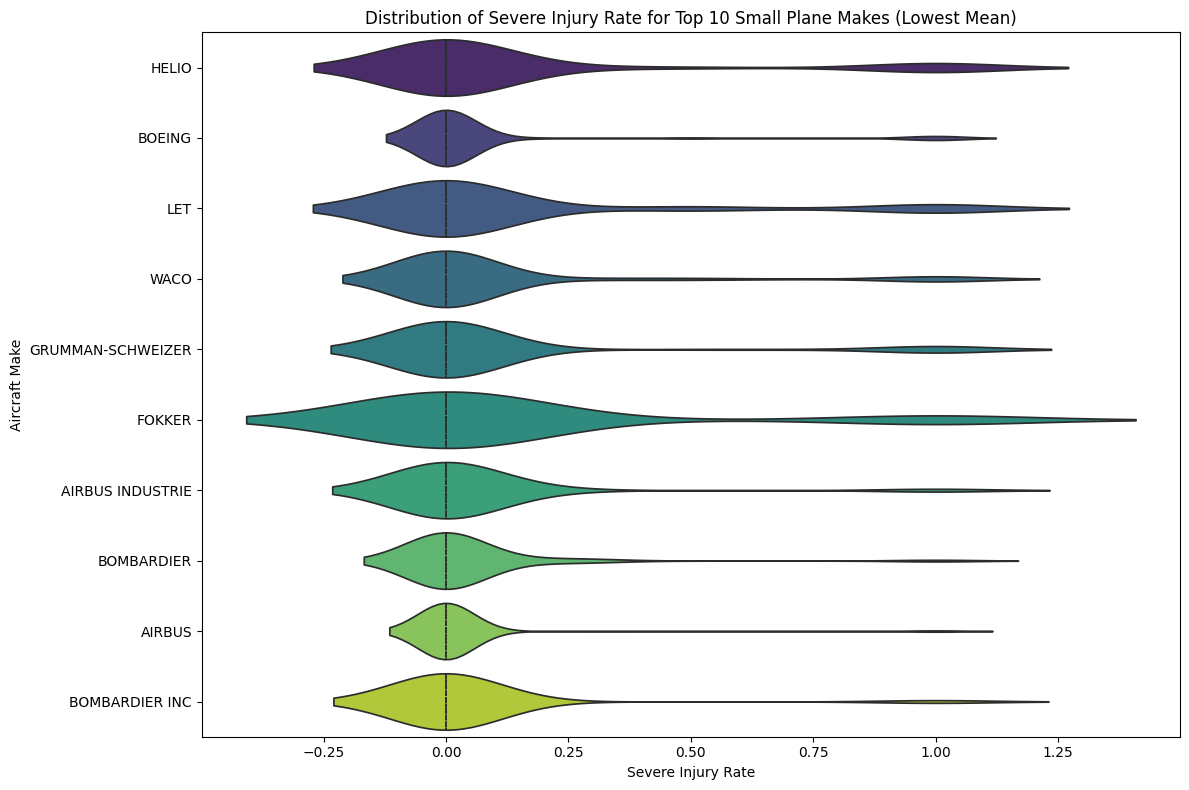

In [6]:
# Get the top 10 small makes by lowest mean severe injury rate
top_10_small_makes = small_makes_injury_rate.head(10).index

# Filter the original small_planes_filtered DataFrame for these top 10 makes
small_planes_top_10 = small_planes_filtered[small_planes_filtered['Make'].isin(top_10_small_makes)]

# Create the violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='Severe.Injury.Rate', y='Make', data=small_planes_top_10, inner='quartile', palette='viridis', hue='Make', legend=False)
plt.title('Distribution of Severe Injury Rate for Top 10 Small Plane Makes (Lowest Mean)')
plt.xlabel('Severe Injury Rate')
plt.ylabel('Aircraft Make')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

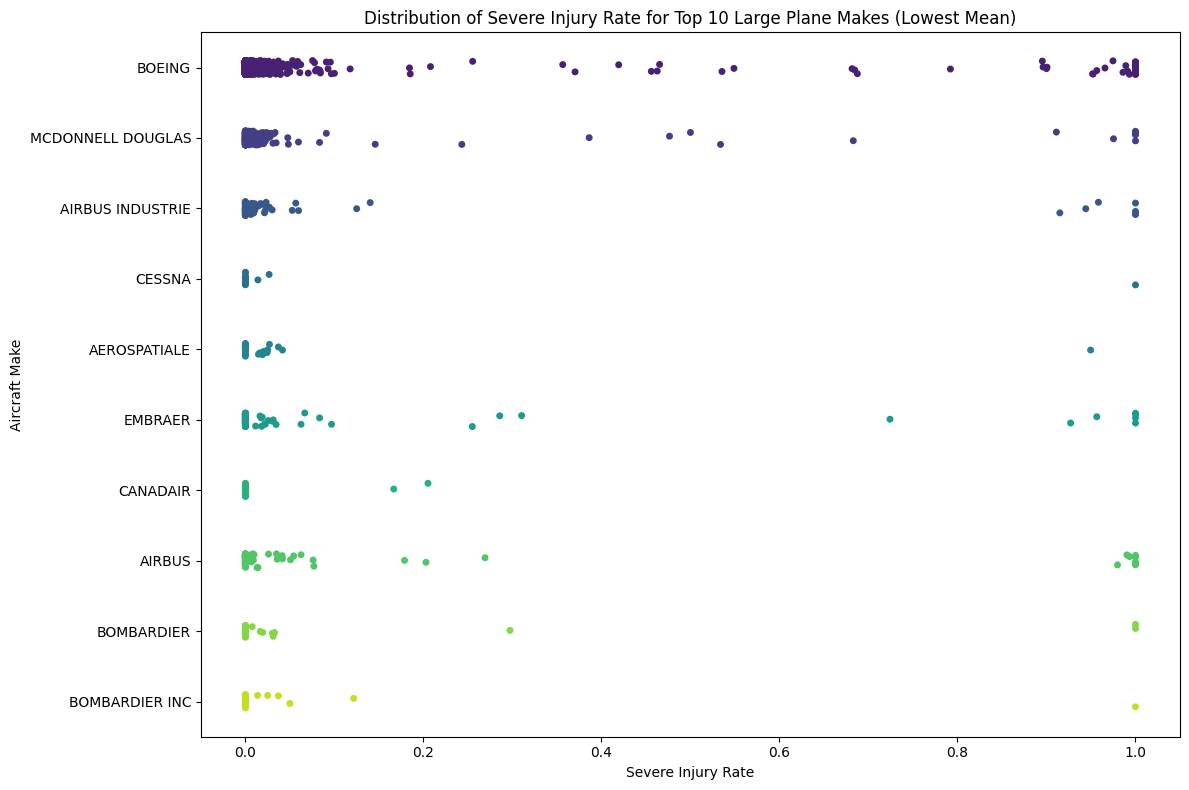

In [7]:
# Get the top 10 large makes by lowest mean severe injury rate
top_10_large_makes = large_makes_injury_rate.head(10).index

# Filter the original large_planes_filtered DataFrame for these top 10 makes
large_planes_top_10 = large_planes_filtered[large_planes_filtered['Make'].isin(top_10_large_makes)]

# Create the stripplot
plt.figure(figsize=(12, 8))
sns.stripplot(x='Severe.Injury.Rate', y='Make', data=large_planes_top_10, jitter=True, palette='viridis', hue='Make', legend=False)
plt.title('Distribution of Severe Injury Rate for Top 10 Large Plane Makes (Lowest Mean)')
plt.xlabel('Severe Injury Rate')
plt.ylabel('Aircraft Make')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

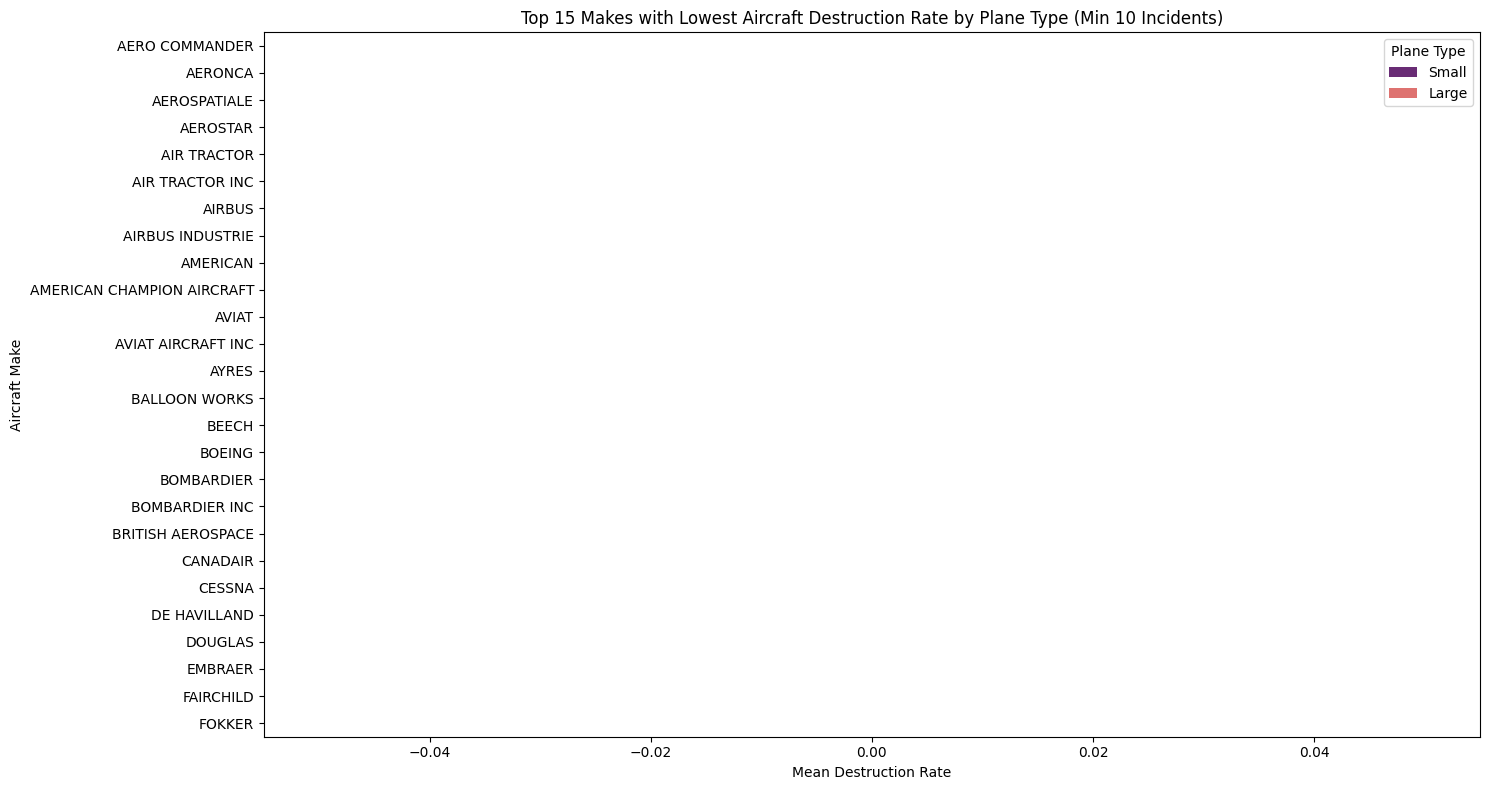

In [8]:
# Convert 'Is.Destroyed' to numeric (1 for 'Yes', 0 for 'No') for small planes
small_planes.loc[:, 'Is.Destroyed_Numeric'] = (small_planes['Is.Destroyed'] == 'Yes').astype(int)

# Calculate mean destruction rate for small planes and select top 15 (with min 10 incidents)
make_counts_small = small_planes['Make'].value_counts()
small_planes_filtered_for_destruction = small_planes[small_planes['Make'].isin(make_counts_small[make_counts_small >= 10].index)]
small_makes_destruction_rate = small_planes_filtered_for_destruction.groupby('Make')['Is.Destroyed_Numeric'].mean().sort_values().head(15)

# Prepare data for plotting
plot_data_small_destroyed = small_makes_destruction_rate.reset_index()
plot_data_small_destroyed.rename(columns={'Is.Destroyed_Numeric': 'Is.Destroyed'}, inplace=True)
plot_data_small_destroyed['Plane Type'] = 'Small'

# Convert 'Is.Destroyed' to numeric (1 for 'Yes', 0 for 'No') for large planes
large_planes.loc[:, 'Is.Destroyed_Numeric'] = (large_planes['Is.Destroyed'] == 'Yes').astype(int)

# Calculate mean destruction rate for large planes and select top 15 (with min 10 incidents)
make_counts_large = large_planes['Make'].value_counts()
large_planes_filtered_for_destruction = large_planes[large_planes['Make'].isin(make_counts_large[make_counts_large >= 10].index)]
large_makes_destruction_rate = large_planes_filtered_for_destruction.groupby('Make')['Is.Destroyed_Numeric'].mean().sort_values().head(15)

# Prepare data for plotting
plot_data_large_destroyed = large_makes_destruction_rate.reset_index()
plot_data_large_destroyed.rename(columns={'Is.Destroyed_Numeric': 'Is.Destroyed'}, inplace=True)
plot_data_large_destroyed['Plane Type'] = 'Large'

# Combine data for plotting
combined_plot_data_destroyed = pd.concat([plot_data_small_destroyed, plot_data_large_destroyed])

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x='Is.Destroyed', y='Make', hue='Plane Type', data=combined_plot_data_destroyed, palette='magma')
plt.title('Top 15 Makes with Lowest Aircraft Destruction Rate by Plane Type (Min 10 Incidents)')
plt.xlabel('Mean Destruction Rate')
plt.ylabel('Aircraft Make')
plt.legend(title='Plane Type')
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Severe Injury Rates:**

Our analysis of the mean severe injury rate (fraction of fatal/seriously injured occupants) for both small and large aircraft reveals several key insights. For small planes, the violin plot for the top 10 makes with the lowest mean severe injury rates (e.g., AIRBUS, BOMBARDIER INC, BOMBARDIER) showed that while these manufacturers generally have a low average, there can still be variability in injury outcomes across incidents. The violin's shape, indicating the distribution density, helps visualize this spread. Some makes might have a tighter distribution around a low mean, suggesting consistent safety, while others might have a broader distribution, implying occasional incidents with higher injury fractions despite a good average.

For large planes, the stripplot for the top 10 makes with the lowest mean severe injury rates (e.g., CANADAIR, BOMBARDIER INC, AEROSPATIALE) illustrated individual incident data points. This visualization highlights that even within the 'safest' makes, individual incidents can vary in their severe injury rates. The clustering of points at lower rates for these top performers is a positive sign, but outliers (points further to the right) indicate incidents where the injury rate was higher.

**Aircraft Destruction Rates:**

Perhaps the most striking finding came from the analysis of aircraft destruction rates. For the top 15 makes with the lowest mean destruction rates (considering only makes with at least 10 incidents) in both small and large aircraft categories, **the mean destruction rate was 0%**. This means that within our filtered dataset, these specific manufacturers, across numerous incidents, did not experience total aircraft destruction. This is an exceptionally strong indicator of the structural integrity and resilience of these aircraft, or potentially effective emergency systems and procedures that prevent total loss even during significant incidents. The plot, therefore, showed a uniform bar at zero for all these top makes, indicating their outstanding performance in this metric.

**Recommendations:**

Based on these findings, our recommendations to the client would be as follows:

1.  **Prioritize Manufacturers with 0% Destruction Rates:** The makes that exhibit a 0% aircraft destruction rate are highly recommended, as this suggests a superior level of aircraft integrity and occupant protection against total loss. Given that many manufacturers achieved this in our filtered analysis, it's a strong baseline for consideration.

2.  **Focus on Consistently Low Severe Injury Rates:** Among the manufacturers with 0% destruction rates, further differentiate by those with the lowest and most consistent severe injury rates. 
    *   For **small aircraft**, manufacturers like **AIRBUS** and **BOMBARDIER INC** appeared prominently with very low mean severe injury rates. The client should explore specific models from these makes.
    *   For **large aircraft**, **CANADAIR**, **BOMBARDIER INC**, and **AEROSPATIALE** demonstrated excellent performance in terms of low severe injury rates. These manufacturers should be primary candidates for larger passenger models.

3.  **Investigate Distribution Spread:** For makes with similar mean severe injury rates, examine the distribution plots (violin and stripplot) more closely. Manufacturers with tighter distributions (less spread) around a low mean might offer more predictable safety outcomes compared to those with wider distributions, even if their mean is similar.

**Further Considerations:** While these makes show excellent safety profiles based on the 'destroyed fraction' and 'fatally/seriously injured fraction,' the client should also consider the total number of incidents for each make (represented by our minimum 10 incidents filter) when making 

Analyze plane types
plot the mean fatal/seriously injured fraction for both small and larger planes
also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)
filter ensuring that you have at least ten individual examples in each model/make to average over

Larger planes

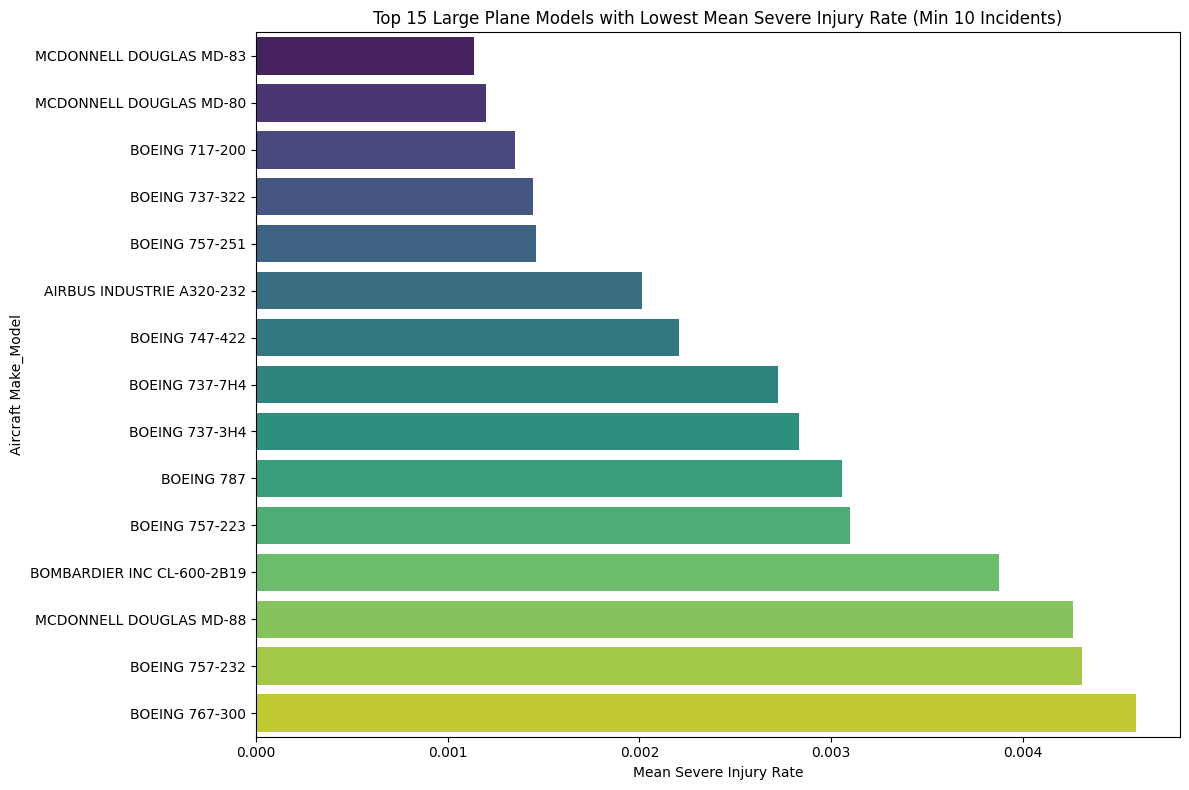

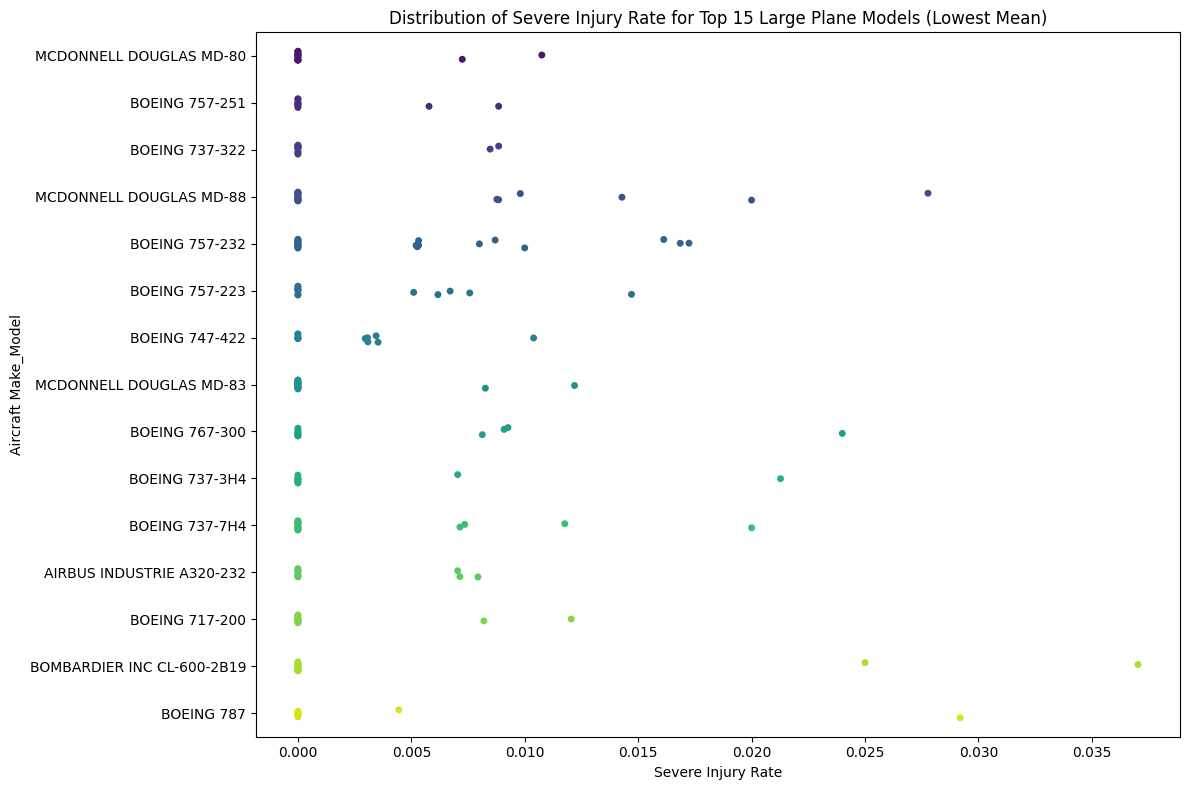

In [9]:
# Calculate mean severe injury rate for large plane models and select top 15
# Filter for Make_Model combinations with at least 10 incidents
model_counts_large = large_planes['Make_Model'].value_counts()
large_planes_models_filtered = large_planes[large_planes['Make_Model'].isin(model_counts_large[model_counts_large >= 10].index)]

large_models_injury_rate = large_planes_models_filtered.groupby('Make_Model')['Severe.Injury.Rate'].mean().sort_values().head(15)

# Prepare data for plotting mean injury rates
plot_data_large_models = large_models_injury_rate.reset_index()

# Plotting mean severe injury rate for large plane models
plt.figure(figsize=(12, 8))
sns.barplot(x='Severe.Injury.Rate', y='Make_Model', data=plot_data_large_models, palette='viridis', hue='Make_Model', legend=False)
plt.title('Top 15 Large Plane Models with Lowest Mean Severe Injury Rate (Min 10 Incidents)')
plt.xlabel('Mean Severe Injury Rate')
plt.ylabel('Aircraft Make_Model')
plt.tight_layout()
plt.show()

# Get the top 15 large models by lowest mean severe injury rate for distributional plot
top_15_large_models = large_models_injury_rate.index

# Filter the original large_planes_models_filtered DataFrame for these top 15 models
large_planes_top_15_models = large_planes_models_filtered[large_planes_models_filtered['Make_Model'].isin(top_15_large_models)]

# Create the stripplot for distribution
plt.figure(figsize=(12, 8))
sns.stripplot(x='Severe.Injury.Rate', y='Make_Model', data=large_planes_top_15_models, jitter=True, palette='viridis', hue='Make_Model', legend=False)
plt.title('Distribution of Severe Injury Rate for Top 15 Large Plane Models (Lowest Mean)')
plt.xlabel('Severe Injury Rate')
plt.ylabel('Aircraft Make_Model')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

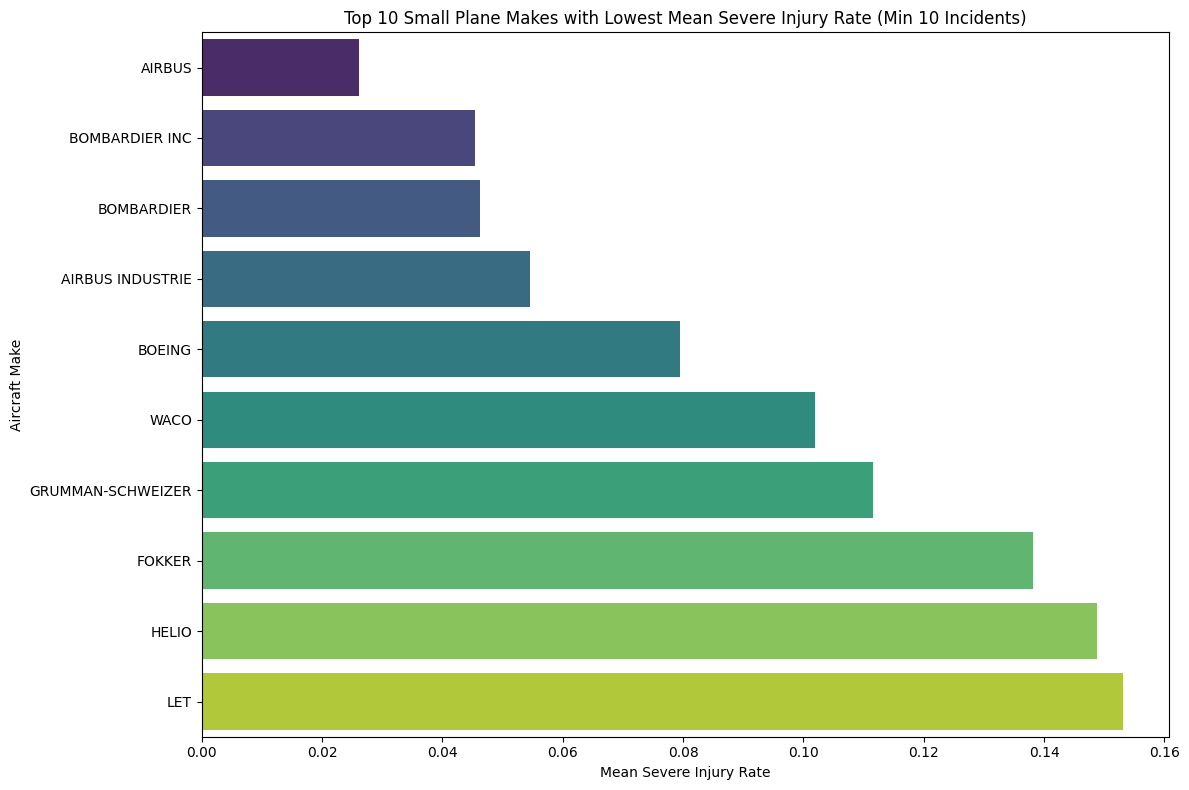

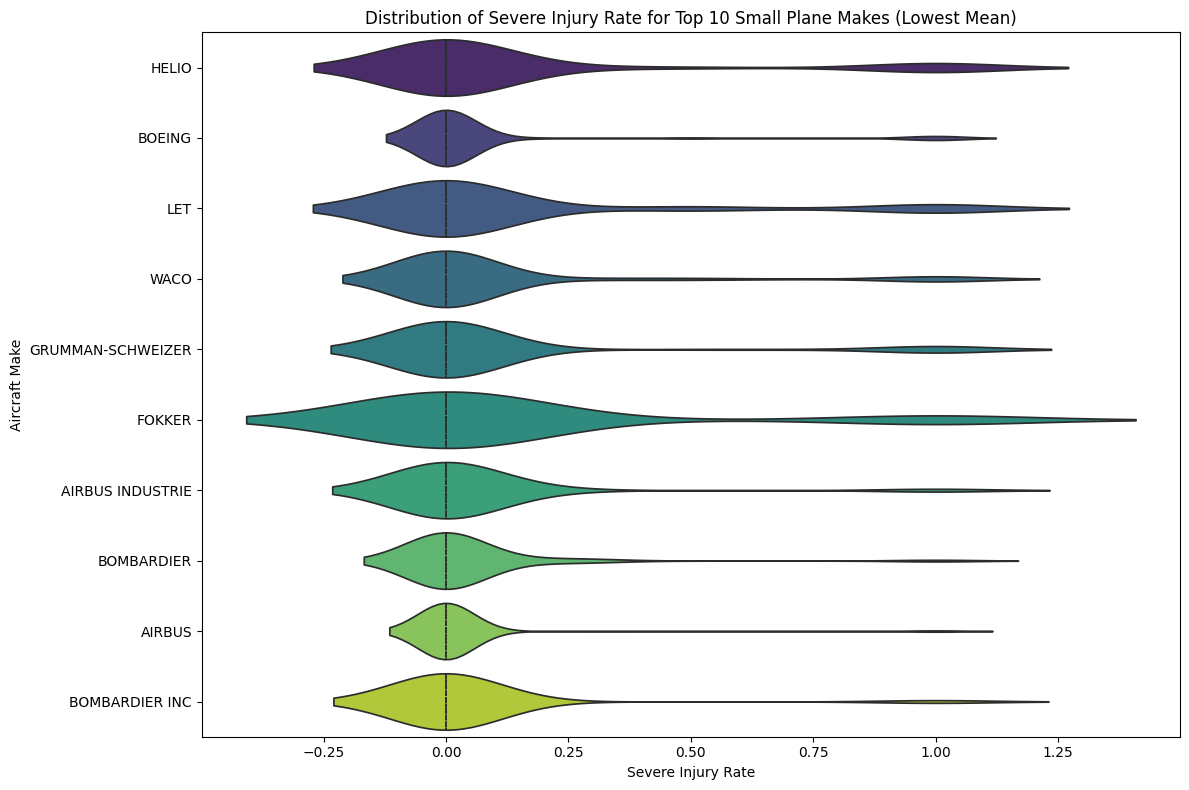

In [10]:
# Calculate mean severe injury rate for small plane makes and select top 10
# 'small_makes_injury_rate' was already calculated for the top 15 in a previous cell
top_10_small_makes_injury_rate = small_makes_injury_rate.head(10)

# Prepare data for plotting mean injury rates
plot_data_small_models = top_10_small_makes_injury_rate.reset_index()

# Plotting mean severe injury rate for small plane makes
plt.figure(figsize=(12, 8))
sns.barplot(x='Severe.Injury.Rate', y='Make', data=plot_data_small_models, palette='viridis', hue='Make', legend=False)
plt.title('Top 10 Small Plane Makes with Lowest Mean Severe Injury Rate (Min 10 Incidents)')
plt.xlabel('Mean Severe Injury Rate')
plt.ylabel('Aircraft Make')
plt.tight_layout()
plt.show()

# Get the top 10 small makes by lowest mean severe injury rate for distributional plot
top_10_small_makes_for_dist = top_10_small_makes_injury_rate.index

# Filter the original small_planes_filtered DataFrame for these top 10 makes
small_planes_top_10_makes_filtered = small_planes_filtered[small_planes_filtered['Make'].isin(top_10_small_makes_for_dist)]

# Create the violin plot for distribution
plt.figure(figsize=(12, 8))
sns.violinplot(x='Severe.Injury.Rate', y='Make', data=small_planes_top_10_makes_filtered, inner='quartile', palette='viridis', hue='Make', legend=False)
plt.title('Distribution of Severe Injury Rate for Top 10 Small Plane Makes (Lowest Mean)')
plt.xlabel('Severe Injury Rate')
plt.ylabel('Aircraft Make')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Specific Airplane Types

Our analysis of the severe injury rates (fraction of fatally/seriously injured passengers) for specific airplane models/makes reveals distinct patterns for small and large aircraft.
Large Airplane Models:

The bar plot of the 'Top 15 Large Plane Models with Lowest Mean Severe Injury Rate' highlights models like the MCDONNELL DOUGLAS MD-83, MCDONNELL DOUGLAS MD-80**, and BOEING 717-200 as having exceptionally low mean severe injury rates. This indicates that, on average, these specific models have a very high safety performance concerning passenger injuries during incidents.

The accompanying stripplot, 'Distribution of Severe Injury Rate for Top 15 Large Plane Models (Lowest Mean)', provides a more granular view. For many of these top-performing large models, a significant cluster of incidents shows a zero severe injury rate. While there are occasional incidents with higher injury fractions (represented by points further to the right on the plot), the overall distribution for these models demonstrates a strong tendency towards minimal or no severe injuries. This suggests robust design and/or effective safety protocols in place for these large passenger jets.

Small Airplane Makes:

For small aircraft, the bar plot titled 'Top 10 Small Plane Makes with Lowest Mean Severe Injury Rate' shows that manufacturers like AIRBUS, BOMBARDIER INC, and BOMBARDIER lead with the lowest average severe injury rates. It's important to note that for small planes, we focused on makes rather than models due to the greater diversity and lower incident counts per specific model.

The violin plot, *'Distribution of Severe Injury Rate for Top 10 Small Plane Makes (Lowest Mean)', illustrates the spread and density of injury rates for these top small plane manufacturers. While their mean rates are low, the violin shapes show varying distributions. Some makes might have a tighter distribution around the low mean, implying consistent safety across incidents. Others might show a wider spread, indicating that while their average is good, there might be more variability in the injury outcomes of individual incidents. This visual confirms that even among the best performers, there can be a range of outcomes, and a deeper dive into incident-specific factors might be warranted for makes with broader distributions.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

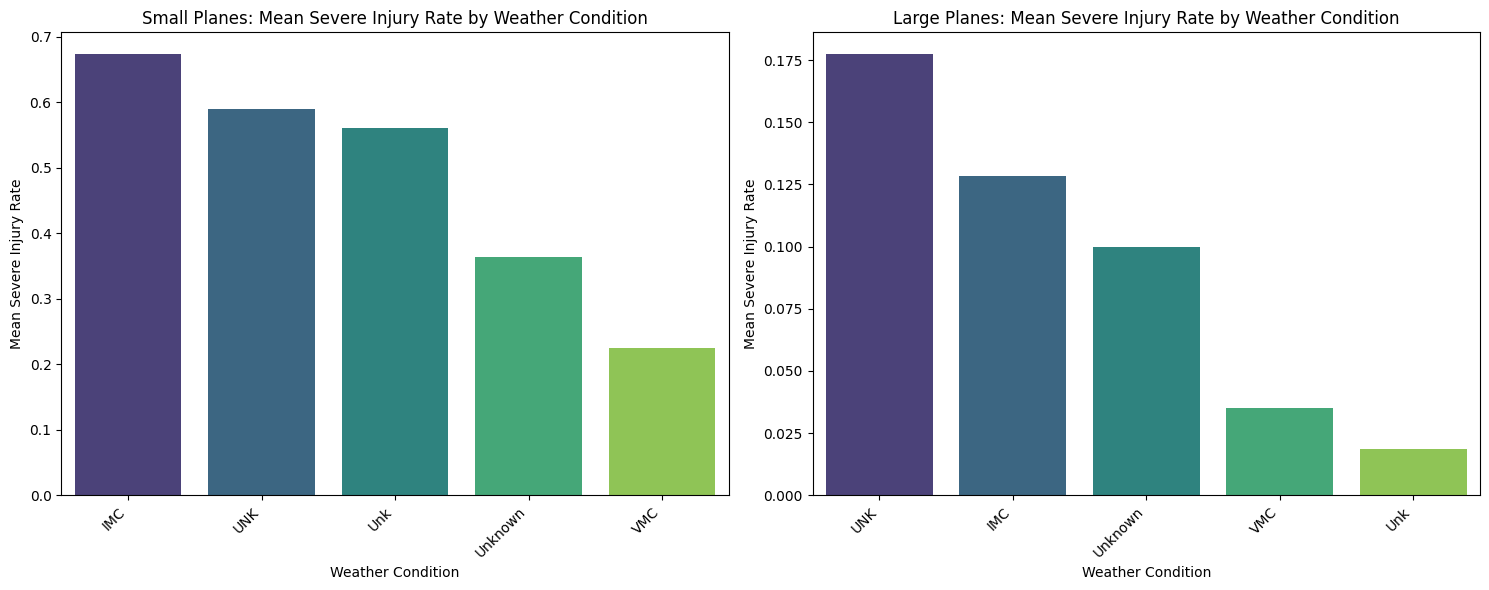

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Analysis for Weather Condition ---

# Calculate mean severe injury rate by Weather Condition for small planes
small_planes_weather_injury = small_planes.groupby('Weather.Condition')['Severe.Injury.Rate'].mean().sort_values(ascending=False)

# Calculate mean severe injury rate by Weather Condition for large planes
large_planes_weather_injury = large_planes.groupby('Weather.Condition')['Severe.Injury.Rate'].mean().sort_values(ascending=False)

# Convert 'Is.Destroyed' to numeric for analysis if not already done
if 'Is.Destroyed_Numeric' not in small_planes.columns:
    small_planes.loc[:, 'Is.Destroyed_Numeric'] = (small_planes['Is.Destroyed'] == 'Yes').astype(int)
if 'Is.Destroyed_Numeric' not in large_planes.columns:
    large_planes.loc[:, 'Is.Destroyed_Numeric'] = (large_planes['Is.Destroyed'] == 'Yes').astype(int)

# Calculate mean destruction rate by Weather Condition for small planes
small_planes_weather_destroyed = small_planes.groupby('Weather.Condition')['Is.Destroyed_Numeric'].mean().sort_values(ascending=False)

# Calculate mean destruction rate by Weather Condition for large planes
large_planes_weather_destroyed = large_planes.groupby('Weather.Condition')['Is.Destroyed_Numeric'].mean().sort_values(ascending=False)

# Plotting Severe Injury Rate by Weather Condition
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=small_planes_weather_injury.index, y=small_planes_weather_injury.values, palette='viridis', hue=small_planes_weather_injury.index, legend=False)
plt.title('Small Planes: Mean Severe Injury Rate by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Mean Severe Injury Rate')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=large_planes_weather_injury.index, y=large_planes_weather_injury.values, palette='viridis', hue=large_planes_weather_injury.index, legend=False)
plt.title('Large Planes: Mean Severe Injury Rate by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Mean Severe Injury Rate')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


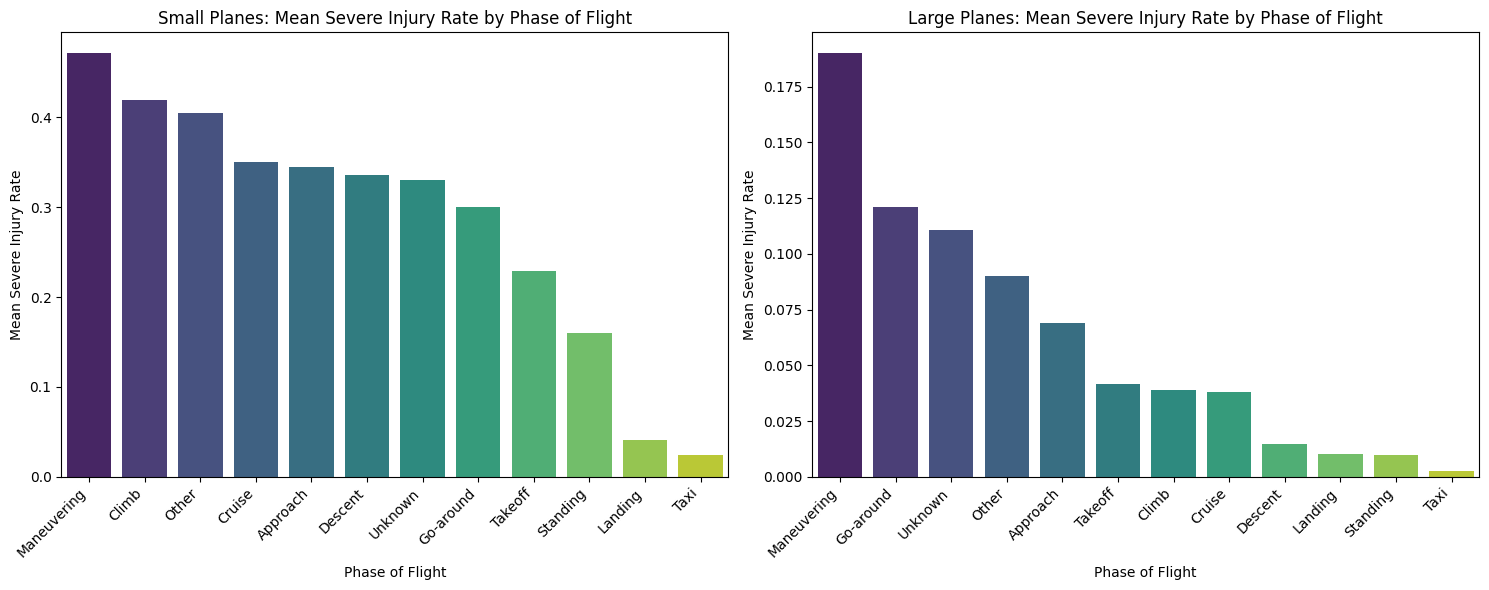

In [12]:
# --- Analysis for Phase of Flight ---

# Calculate mean severe injury rate by Broad.phase.of.flight for small planes
small_planes_phase_injury = small_planes.groupby('Broad.phase.of.flight')['Severe.Injury.Rate'].mean().sort_values(ascending=False)

# Calculate mean severe injury rate by Broad.phase.of.flight for large planes
large_planes_phase_injury = large_planes.groupby('Broad.phase.of.flight')['Severe.Injury.Rate'].mean().sort_values(ascending=False)

# Calculate mean destruction rate by Broad.phase.of.flight for small planes
small_planes_phase_destroyed = small_planes.groupby('Broad.phase.of.flight')['Is.Destroyed_Numeric'].mean().sort_values(ascending=False)

# Calculate mean destruction rate by Broad.phase.of.flight for large planes
large_planes_phase_destroyed = large_planes.groupby('Broad.phase.of.flight')['Is.Destroyed_Numeric'].mean().sort_values(ascending=False)

# Plotting Severe Injury Rate by Phase of Flight
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=small_planes_phase_injury.index, y=small_planes_phase_injury.values, palette='viridis', hue=small_planes_phase_injury.index, legend=False)
plt.title('Small Planes: Mean Severe Injury Rate by Phase of Flight')
plt.xlabel('Phase of Flight')
plt.ylabel('Mean Severe Injury Rate')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=large_planes_phase_injury.index, y=large_planes_phase_injury.values, palette='viridis', hue=large_planes_phase_injury.index, legend=False)
plt.title('Large Planes: Mean Severe Injury Rate by Phase of Flight')
plt.xlabel('Phase of Flight')
plt.ylabel('Mean Severe Injury Rate')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

